<a href="https://colab.research.google.com/github/hye0-n0/AI_finance/blob/main/Session_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AI for finance [IE471]

### Hands-on Practice on Session #1
### [Session 1] Common factors affecting bond returns via PCA

1. PCA applied to finance: PCA Analysis [HW]

2. T-SNE: Analyze Level, Slope and Curvature using Dimension reduction algorithm except PCA.


### Preparation


- in this chapter, we use the daily treasury par yield curve rate in U.S. department of the treasury. Data can be found at the following links: [Click yield curve rate Dataset]("https://www.treasury.gov/resource-center/data-chart-center/interest-rates/Pages/TextView.aspx?data=yieldAll")
- If you are interested in python crawling, you can easily collect data using beautifulsoup package.

In [ ]:
import numpy as np
import pandas as pd
import requests
import datetime
import os
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

## 1. PCA applied to finance: PCA Analysis [HW]
- Perform PCA by filling in the blanks mentioned in Slide 15 and interpret the results.

In [ ]:
import scipy

def PCA_solver(df, num_reconstruct):

    dataset = df.copy()

    # Fill in the code!
    # Step 1   : Compute mean-centered data matr
    mean_vector = np.mean(dataset, axis=0)
    centered_data = dataset - mean_vector

    # Step 2-1 : Compute Covariance matrix
    cov_matrix = np.cov(centered_data, rowvar=False)  # row:obs, cloumns:variable

    # Step 2-2 : Use the function scipy.linalg.eigh
    eigenvals, eigenvecs = scipy.linalg.eigh(cov_matrix)

    eigenvecs = eigenvecs[:, np.argsort(eigenvals)[::-1]]
    eigenvals = eigenvals[np.argsort(eigenvals)[::-1]]
    eigenvecs = eigenvecs[:, :num_reconstruct]

    return np.dot(eigenvecs.T, df.T).T, eigenvals, eigenvecs

In [ ]:
bond_data = pd.read_csv("bond_data.csv").iloc[:, 1:]

scores, evals, evecs = PCA_solver(bond_data, 3)

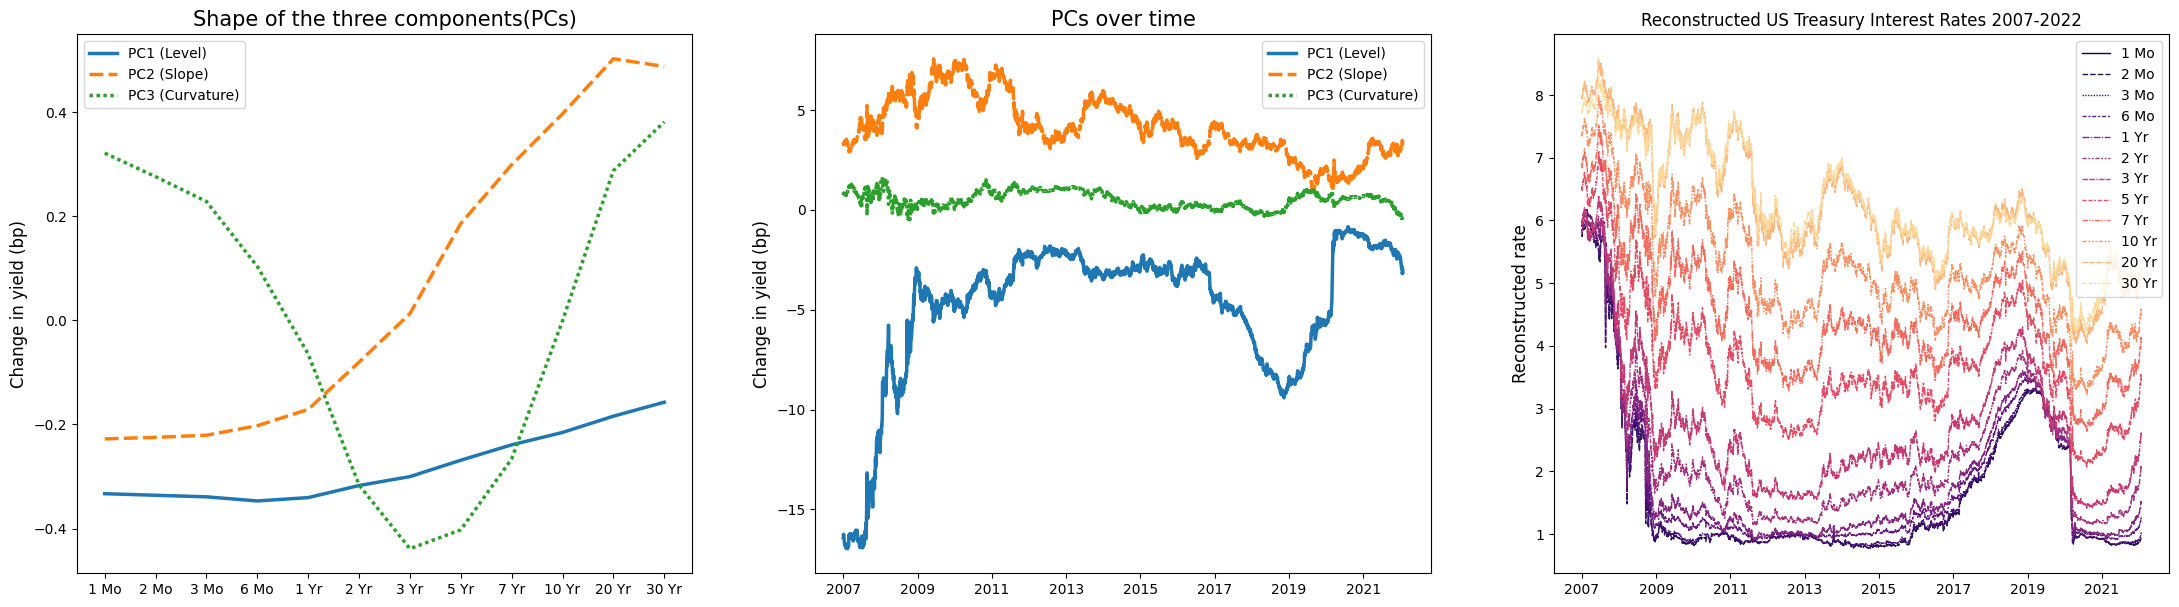

In [ ]:
evecs = pd.DataFrame(evecs)
score = pd.DataFrame(scores)

fig, axes = plt.subplots(1, 3, figsize=(27,7))

sns.lineplot(data=evecs.iloc[:, :3],  linewidth=2.5, ax = axes[0])
axes[0].set_title("Shape of the three components(PCs)", fontsize = 15)
axes[0].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[0].set_xticks([0,1,2,3,4,5,6,7,8,9,10,11],['1 Mo', '2 Mo', '3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr',  '10 Yr', '20 Yr', '30 Yr'])
#axes[0].legend(labels=["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"])
# Seaborn may not link the correct lines to labels automatically when plotting multiple columns at once,
# so I manually extract handles and labels to force the correct legend display.
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles[:3], labels=["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"])


sns.lineplot(data=score.iloc[:, :3],  linewidth=2.5, ax = axes[1])
axes[1].set_title("PCs over time", fontsize = 15)
axes[1].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[1].set_xticks([0,500,1000,1500,2000,2500,3000,3500],['2007','2009','2011','2013','2015','2017','2019','2021'])
#axes[1].legend(labels=["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"])
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles[:3], labels=["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"])

reconst = pd.DataFrame(np.dot(scores,evecs.T), index=bond_data.index, columns=bond_data.columns)
reconst += bond_data.iloc[:, 1:].mean(axis = 0 )
sns.lineplot(data=reconst,  linewidth=1.0, palette = "magma")
axes[2].set_title("Reconstructed US Treasury Interest Rates 2007-2022", fontsize = 12)
axes[2].set_xticks([0,500,1000,1500,2000,2500,3000,3500],['2007','2009','2011','2013','2015','2017','2019','2021'])
axes[2].set_ylabel("Reconstructed rate", fontsize = 12)

plt.savefig("Figure_7.png")

plt.show()

### Interpret the results

As a result of performing PCA, the variation in the overall yield curve can be summarized into three common factors: Level, Slope, and Curvature.

---------------------------
#### In the 1st graph,
- The first principal component (PC1) captures changes in the overall level of interest rates across all maturities.
- The second component (PC2) explains the difference between short- and long-term rates, indicating the slope of the yield curve.
- The third component (PC3) reflects curvature, mainly influencing the medium-term maturities.

---------------------------
#### In the 2nd graph(PCs over time),

- **PC1 (Level)** captures the overall level of interest rates across all maturities and reflects broad movements in monetary policy and macroeconomic conditions.Its fluctuations correspond closely with major economic cycles, showing both bearish and bullish phases over time.
  - 2007–2009: Sharp decline during the Global Financial Crisis due to aggressive Fed rate cuts, indicating a bearish shift.
  - 2017–2018: Gradual rise with U.S. economic growth and Fed rate hikes, reflecting bullish sentiment.
  - 2019–2020: Steep drop amid COVID-19 and emergency easing,signaling a return to bearish conditions.

- **PC2 (Slope)** shows a value below a certain point in response to macroeconomic and financial shocks. It dips below about 5 at several key points, reflecting periods when the yield curve flattens or inverts — a pattern that frequently aligns with major economic or financial crises.
  - 2007–2009: Yield curve inversion(flattening) during the housing bubble and global financial crisis
  - 2011: European debt crisis and the U.S. credit rating downgrade
  - 2015: Global market turbulence, including concerns over China’s economic slowdown and a sharp 1,000-point drop in the Dow Jones
  - 2019–2020: Inversion(flattening) of the yield curve preceding the COVID-19 recession

- **PC3 (Curvature)** remains relatively stable over time but shows noticeable fluctuations during and after major crises, such as:
  - 2008: Global Financial Crisis
  - 2019: COVID-19 pandemic


---------------------------
In the 3rd graph,

The yield curve reconstructed using the top three principal components almost replicates the dynamics of the original yield data. This demonstrates the effectiveness of dimensionality reduction in capturing the essential structure of the term structure of interest rates.

However, during periods of extreme volatility (2007–2008 and 2019–2020), some differences remain, possibly due to the influence of higher-order components not included in the reconstruction.

---------------------------

Overall, three common factors (Level, Slope, and Curvature) capture major economic events

## 2. Isomap: Analyze Level, Slope and Curvature using Dimension reduction algorithm except PCA.
**Isomap (Isometric Mapping)** is a nonlinear dimensionality reduction technique that extends classical Multidimensional Scaling (MDS).
It preserves the geodesic (manifold) distances between data points, making it effective for uncovering the underlying nonlinear structure in high-dimensional data.

Isomap is particularly useful when the data lies on a curved manifold, as it can capture relationships that linear methods like PCA may miss.

In [ ]:
from sklearn.manifold import Isomap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the data
bond_data = pd.read_csv("bond_data.csv").iloc[:, 1:]

# Standardize the data before applying Isomap
# This ensures that all features contribute equally to distance calculations
scaler = StandardScaler()
scaled_bond = scaler.fit_transform(bond_data)

# Use Isomap to reduce dimension to 3
isomap = Isomap(n_components=3, n_neighbors=110)
isomap_scores = isomap.fit_transform(scaled_bond)  # shape: (n_samples, 3)

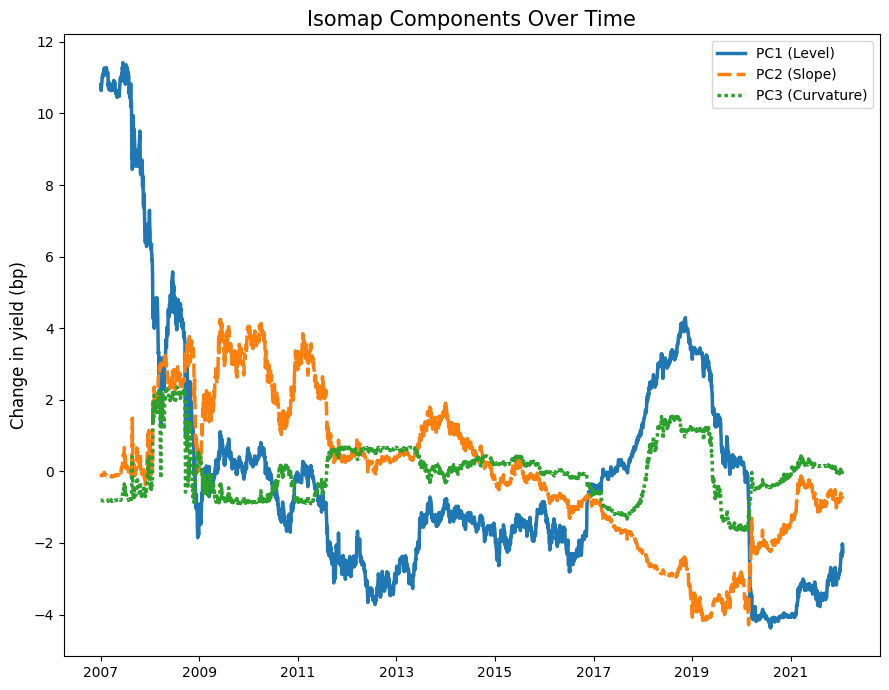

In [ ]:
# Convert to DataFrame
isomap_df = pd.DataFrame(isomap_scores, columns=["IC1 (Level)", "IC2 (Slope)", "IC3 (Curvature)"])

# Set up plot
fig, ax = plt.subplots(figsize=(9, 7))

# Plot: Isomap components (scores over time)
sns.lineplot(data=isomap_df, linewidth=2.5, ax=ax)
ax.set_title("Isomap Components Over Time", fontsize=15)
ax.set_ylabel("Change in yield (bp)", fontsize = 12)
ax.set_xticks([0,500,1000,1500,2000,2500,3000,3500])
ax.set_xticklabels(['2007','2009','2011','2013','2015','2017','2019','2021'])
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[:3], labels=["PC1 (Level)", "PC2 (Slope)", "PC3 (Curvature)"])


plt.tight_layout()
plt.savefig("Isomap_Analysis.png")
plt.show()

### Interpret the results

The figure shows the time series of the top three Isomap components (ICs) extracted from U.S. Treasury yield curve data from 2007 to 2022. Unlike PCA, which is a linear dimensionality reduction method,

Each component is interpreted Level (IC1), Slope (IC2), and Curvature (IC3).

---------------------------
#### In "Isomap Components over time" Figure,

- **IC1 (Level)** reflects the overall level of interest rates and captures the most dominant trend in the data. It tracks shifts in monetary policy and market sentiment, serving as the Level factor in the yield curve.
  - 2007 to 2009: sharp decline corresponds to a strong bearish phase, as the Global Financial Crisis prompted aggressive interest rate cuts and a widespread shift toward safe assets in the bond market.
  - 2017 to 2018: modest recovery, signaling a mild bullish sentiment. This likely reflects the Federal Reserve’s rate hikes during a period of stronger U.S. economic growth and normalization of monetary policy.
  - 2020: plunges again amid the COVID-19 crisis, marking another highly bearish episode driven by emergency rate cuts and heightened demand for risk-free assets.

- **IC2 (Slope)** captures the difference between short- and long-term interest rates, reflecting the steepness or inversion of the yield curve. At several points, it takes on negative values, which coincide with periods of yield curve inversion — a phenomenon where short-term interest rates exceed long-term rates, often signaling upcoming economic downturns.
  - 2007 to 2009: Clear decline reflects a flattening yield curve as the financial crisis worsens and short-term rates approach the zero lower bound.
  - 2013: Near zero while gradually declining, aligning with a drop in the U.S. stock market.
  - 2019 to 2016: Another drop appears amid global market uncertainty, including China’s economic slowdown and commodity price collapse.
  - 2019 to 2021: Decline highlights yield curve inversion(flattening) risks during the COVID-19 crisis.

- **IC3 (Curvature)** captures changes in the shape of the yield curve, especially around medium-term maturities. It reflects nonlinear shifts in investor expectations about interest rates and the economy. IC3 is relatively stable compared to other components, but shows noticeable fluctuations during and after major crises.
  - 2008 to 2009:  Increase suggests mid-curve tension as markets respond to extended low-rate forward guidance during the Global Financial Crisis.
  - 2018 to 2020: Upward trend indicates rising curvature, driven by tightening monetary policy and increased uncertainty—followed by a rapid reversal as the entire yield curve flattens under emergency easing, reducing curvature once again.

---------------------------
#### Summary
Overall, the Level (IC1), Slope (IC2), and Curvature (IC3) components derived from Isomap closely resemble the patterns observed in PCA.

While PCA captures linear relationships within the yield curve data, Isomap provides a nonlinear perspective, allowing for the detection of more subtle and complex structures—especially during periods of heightened market stress.

The consistency in the interpretation of all three components across both methods reinforces their economic meaning and highlights the robustness of the level-slope-curvature framework in modeling yield curve dynamics over time.